In [1]:
pip install xgboost scikit-learn pandas matplotlib seaborn


📊 MODEL ACCURACY
Train Accuracy : 1.0
Test Accuracy  : 0.988
✅ Model generalization looks good

📋 Classification Report
              precision    recall  f1-score   support

 No Scarcity       0.99      0.99      0.99       270
    Scarcity       0.99      0.98      0.98       162

    accuracy                           0.99       432
   macro avg       0.99      0.99      0.99       432
weighted avg       0.99      0.99      0.99       432



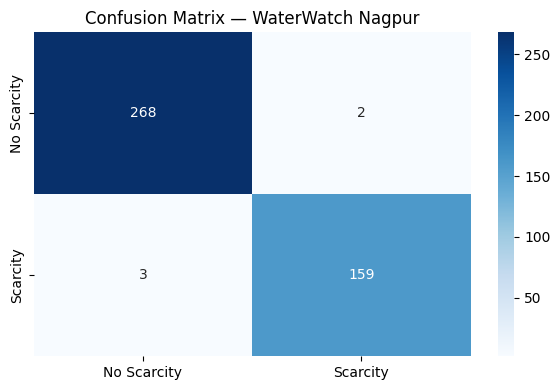


🔍 Feature Importance
                 feature  importance
0           supply_hours    0.578282
4             complaints    0.199571
6  supply_hours_7day_avg    0.129936
3                 supply    0.054051
1               pressure    0.010064
7    complaints_7day_avg    0.009642
5            pipe_breaks    0.007550
2                 demand    0.006703
8   pipe_breaks_7day_avg    0.004201

✅ ward_risk_predictions.csv saved
✅ feature_importance.csv saved


In [30]:
# ─── STEP 1 — IMPORTS ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# ─── STEP 2 — LOAD DATA ─────────────────────────────────
df = pd.read_csv("/content/waterwatch_dataset  (1).csv")
df.columns = df.columns.str.lower().str.strip()

# CREATE 7-DAY FEATURES
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values(["ward_id", "date"])

df["supply_hours_7day_avg"] = df.groupby("ward_id")["supply_hours"]\
    .transform(lambda x: x.rolling(7, min_periods=1).mean())

df["complaints_7day_avg"] = df.groupby("ward_id")["complaints"]\
    .transform(lambda x: x.rolling(7, min_periods=1).mean())

df["pipe_breaks_7day_avg"] = df.groupby("ward_id")["pipe_breaks"]\
    .transform(lambda x: x.rolling(7, min_periods=1).mean())

# ─── STEP 3 — FEATURES ──────────────────────────────────
features = [
    "supply_hours",
    "pressure",
    "demand",
    "supply",
    "complaints",
    "pipe_breaks",
    "supply_hours_7day_avg",
    "complaints_7day_avg",
    "pipe_breaks_7day_avg"
]

target = "scarcity"

X = df[features]
y = df[target]

# ─── STEP 4 — TRAIN TEST SPLIT ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ─── STEP 5 — TRAIN MODEL ───────────────────────────────
model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# ─── STEP 6 — ACCURACY CHECK ────────────────────────────
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\n📊 MODEL ACCURACY")
print("Train Accuracy :", round(train_acc, 3))
print("Test Accuracy  :", round(test_acc, 3))

# Overfitting warning
if train_acc - test_acc > 0.08:
    print("⚠️ Warning: Model may be overfitting")
else:
    print("✅ Model generalization looks good")

# Detailed metrics
print("\n📋 Classification Report")
print(classification_report(
    y_test,
    test_pred,
    target_names=["No Scarcity", "Scarcity"]
))

# ─── STEP 7 — CONFUSION MATRIX ──────────────────────────
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Scarcity", "Scarcity"],
    yticklabels=["No Scarcity", "Scarcity"]
)

plt.title("Confusion Matrix — WaterWatch Nagpur")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ─── STEP 8 — FEATURE IMPORTANCE ────────────────────────
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n🔍 Feature Importance")
print(importance)

# ─── STEP 9 — PREDICT NEXT WEEK ─────────────────────────
latest = df.sort_values("date").groupby("ward_id").tail(7)
ward_avg = latest.groupby("ward_id")[features].mean().reset_index()

ward_avg["risk_score"] = model.predict_proba(
    ward_avg[features]
)[:, 1] * 100

# Smooth extreme probabilities
ward_avg["risk_score"] = ward_avg["risk_score"].clip(10, 90)
ward_avg["risk_score"] = ward_avg["risk_score"].round(1)

ward_avg["risk_level"] = pd.cut(
    ward_avg["risk_score"],
    bins=[0, 35, 65, 100],
    labels=["🟢 Low", "🟡 Medium", "🔴 High"]
)

# Add placeholder columns if they don't exist to prevent KeyError
if 'ward_name' not in df.columns:
    df['ward_name'] = df['ward_id'].apply(lambda x: f"Ward_{x}")
if 'zone' not in df.columns:
    df['zone'] = df['ward_id'].apply(lambda x: f"Zone_{(int(x.replace('W','')) % 3) + 1}")

ward_names = df[["ward_id", "ward_name", "zone"]].drop_duplicates()
ward_avg = ward_avg.merge(ward_names, on="ward_id")

# ─── STEP 10 — TANKER RECOMMENDATION ────────────────────
def recommend_tankers(row):
    gap = row["demand"] - row["supply"]
    risk = row["risk_score"]
    base = max(0, int(gap * 6))

    if risk > 70:
        return base + 3
    elif risk > 40:
        return base + 1
    return base

ward_avg["tankers_needed"] = ward_avg.apply(
    recommend_tankers, axis=1
)

# ─── STEP 11 — SAVE ─────────────────────────────────────
ward_avg.to_csv("ward_risk_predictions.csv", index=False)
importance.to_csv("feature_importance.csv", index=False)

print("\n✅ ward_risk_predictions.csv saved")
print("✅ feature_importance.csv saved")